# Bandit Problem

In [192]:
# imports
from bandits import Bandit
import random
import numpy as np
import matplotlib.pyplot as plt


A list of ten bandit objects initialized in the list...

In [ ]:
bandits = [Bandit(np.random.random()*4-2) for _ in range(10)]

In [194]:

bandits[0].pullLever()

0.5263168585155379

## Greedy algorithm Implementation

In [195]:
def run_greedy(iterations):
    Bandit_reward=np.zeros(len(bandits))
    Times_Called=np.zeros(len(bandits))
    rewards=[]

    for _ in range(iterations):

        best_choice=np.argmax(Bandit_reward)
        reward=bandits[best_choice].pullLever()
        Times_Called[best_choice]+=1
        Bandit_reward[best_choice]+=(reward-Bandit_reward[best_choice])/Times_Called[best_choice]

        rewards.append(reward)

    
    return rewards


Plot the cumulative average of rewards as the number of iterations increases.

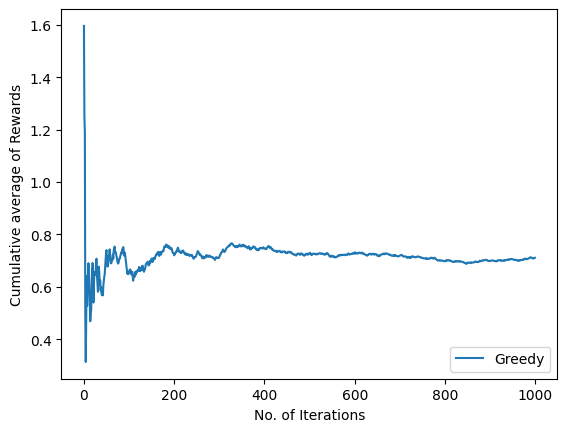

In [ ]:
iterations=1000
Rewards=run_greedy(iterations)
Cumsum_average_rewards=np.cumsum(Rewards)/(np.arange(iterations)+1)

plt.plot(Cumsum_average_rewards)
plt.xlabel("No. of Iterations")
plt.ylabel("Cumulative average of Rewards")
plt.legend(["Greedy"],loc="lower right")

## $\epsilon$-greedy Algorithm

In [ ]:
def run_epsilon_greedy(epsilon,iterations):
    Q=np.zeros(len(bandits))
    N=np.zeros(len(bandits))
    rewards=[]

    for _ in range(iterations):
        if np.random.random() <epsilon:
            choice=np.random.randint(0,len(bandits))
        else:
            choice=np.argmax(Q)
        
        reward=bandits[choice].pullLever()
        N[choice]+=1
        Q[choice]+=(reward-Q[choice])/N[choice]
        rewards.append(reward)

    return rewards

Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

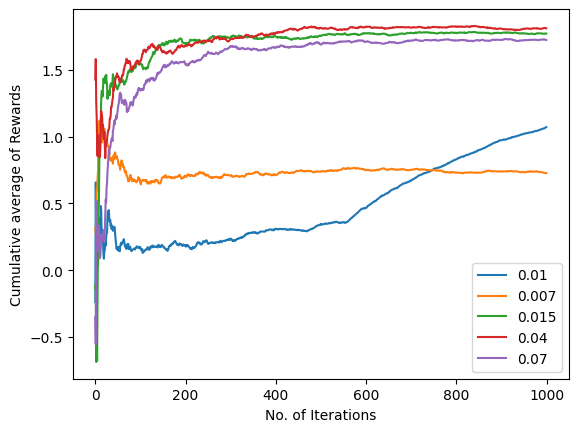

In [198]:
iterations=1000
Epsilon=[0.01,0.007,0.015,0.04,0.07]
for ep in Epsilon:
    Rewards=run_epsilon_greedy(ep,iterations)
    Cumsum_average_rewards=np.cumsum(Rewards)/(np.arange(iterations)+1)
    plt.plot(Cumsum_average_rewards)

plt.xlabel("No. of Iterations")
plt.ylabel("Cumulative average of Rewards")
plt.legend([ep for ep in Epsilon],loc="lower right")

## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

In [ ]:
Epsilon=np.linspace(0,1,100)
Final_Rewards=[]
for ep in Epsilon:
    Rewards=run_epsilon_greedy(ep,iterations)
    Final_Rewards.append(np.mean(Rewards))

Text(0, 0.5, 'Final Cumulative average of Rewards')

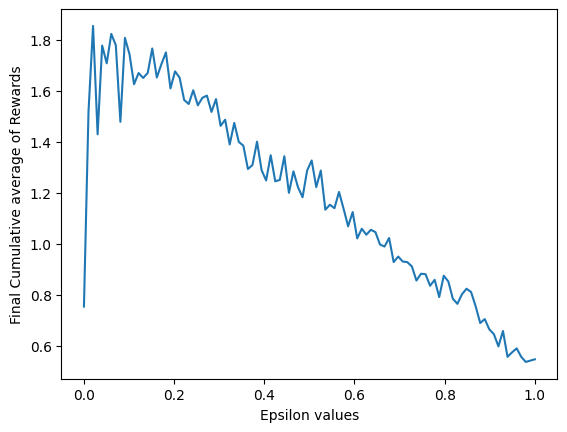

In [200]:
plt.plot(Epsilon,Final_Rewards)

plt.xlabel("Epsilon values")
plt.ylabel("Final Cumulative average of Rewards")

## Optimistic Initial Values

In [ ]:
def run_optimistic_greedy(iterations,optimistic_value=10):
    Bandit_reward=np.ones(len(bandits))*optimistic_value
    Times_Called=np.zeros(len(bandits))
    rewards=[]

    for _ in range(iterations):

        best_choice=np.argmax(Bandit_reward)
        reward=bandits[best_choice].pullLever()
        Times_Called[best_choice]+=1
        Bandit_reward[best_choice]+=(reward-Bandit_reward[best_choice])/Times_Called[best_choice]

        rewards.append(reward)

    
    return rewards


Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$

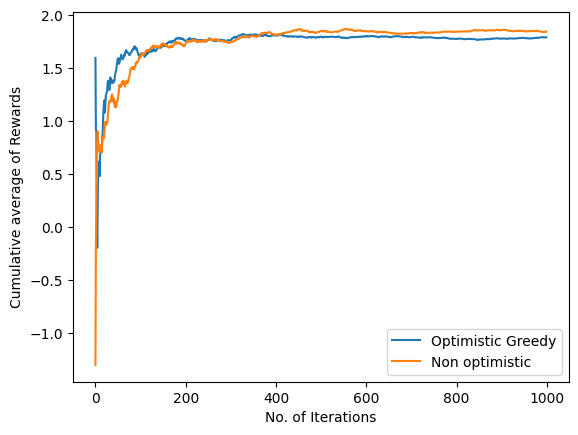

In [ ]:
iterations=1000
Rewards=run_optimistic_greedy(iterations,10)
Cumsum_average_rewards=np.cumsum(Rewards)/(np.arange(iterations)+1)

plt.plot(Cumsum_average_rewards)
Rewards=run_epsilon_greedy(0.1,iterations)
Cumsum_average_rewards=np.cumsum(Rewards)/(np.arange(iterations)+1)

plt.plot(Cumsum_average_rewards)


plt.xlabel("No. of Iterations")
plt.ylabel("Cumulative average of Rewards")
plt.legend(["Optimistic Greedy","Non optimistic"],loc="lower right")

In [203]:
#UCB Skipped